# Operations Dashboard

This dashboard provides operational insights for each depot:

1. **Demand Accuracy** - Predicted vs Actual Passenger KMs (last 30 days)
2. **Supply Accuracy** - Estimated vs Actual KMs (last 30 days)
3. **Daily Schedule** - Current schedule table

---

## 1. Setup & Configuration

In [24]:
# =============================================================================
# IMPORTS
# =============================================================================
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, date, timedelta
import warnings

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

# Try to import plotly for interactive charts
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly not available. Using matplotlib for visualizations.")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 50)
warnings.filterwarnings('ignore')

# Matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports loaded successfully")
print(f"Plotly available: {PLOTLY_AVAILABLE}")

Plotly not available. Using matplotlib for visualizations.
Imports loaded successfully
Plotly available: False


In [25]:
# =============================================================================
# PROJECT PATHS
# =============================================================================

# Project root - find dynamically by looking for marker directories
def find_project_root():
    """Find project root by looking for data/ or model/ directory."""
    candidates = [
        Path("..").resolve(),           # If running from notebooks/
        Path(".").resolve(),            # If running from project root
        Path(__file__).parent.parent if '__file__' in dir() else None,
    ]
    
    for candidate in candidates:
        if candidate and (candidate / "data").exists() and (candidate / "model").exists():
            return candidate
    
    # Fallback: explicit path
    fallback = Path("/home/sr/agnigent/ai_agents/dynamic_scheduling")
    if fallback.exists():
        return fallback
    
    raise RuntimeError("Could not find project root. Expected data/ and model/ directories.")

PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output"

# Data files
PREDICTIONS_FILE = OUTPUT_DIR / "predictions" / "daily_predictions.parquet"
GOLD_MASTER_PARQ = DATA_DIR / "processed" / "ops_daily_gold.parquet"
SCHEDULE_DIR = OUTPUT_DIR / "dynamic_schedule"

# Dashboard configuration
DASHBOARD_CONFIG = {
    "lookback_days": 30,  # Number of days to show in accuracy charts
    "date_format": "%Y-%m-%d",
    "chart_height": 400,
    "table_rows": 30,
}

print("PROJECT_ROOT     :", PROJECT_ROOT)
print("PREDICTIONS_FILE :", PREDICTIONS_FILE, f"(exists: {PREDICTIONS_FILE.exists()})")
print("GOLD_MASTER_PARQ :", GOLD_MASTER_PARQ, f"(exists: {GOLD_MASTER_PARQ.exists()})")
print("SCHEDULE_DIR     :", SCHEDULE_DIR, f"(exists: {SCHEDULE_DIR.exists()})")

PROJECT_ROOT     : /home/sr/agnigent/ai_agents/dynamic_scheduling
PREDICTIONS_FILE : /home/sr/agnigent/ai_agents/dynamic_scheduling/output/predictions/daily_predictions.parquet (exists: True)
GOLD_MASTER_PARQ : /home/sr/agnigent/ai_agents/dynamic_scheduling/data/processed/ops_daily_gold.parquet (exists: True)
SCHEDULE_DIR     : /home/sr/agnigent/ai_agents/dynamic_scheduling/output/dynamic_schedule (exists: True)


## 2. Data Loading

In [26]:
# =============================================================================
# DATA LOADING FUNCTIONS
# =============================================================================

def load_predictions_data(file_path: Path, lookback_days: int = 30) -> pd.DataFrame:
    """
    Load predictions data for the last N days.
    """
    if not file_path.exists():
        print(f"Predictions file not found: {file_path}")
        return pd.DataFrame()
    
    df = pd.read_parquet(file_path)
    df["prediction_date"] = pd.to_datetime(df["prediction_date"])
    df["run_date"] = pd.to_datetime(df["run_date"])
    
    # Filter to last N days
    cutoff_date = pd.Timestamp.now() - pd.Timedelta(days=lookback_days)
    df = df[df["prediction_date"] >= cutoff_date]
    
    return df.sort_values(["depot", "prediction_date"])


def load_gold_data(file_path: Path, lookback_days: int = 30) -> pd.DataFrame:
    """
    Load GOLD data for the last N days.
    """
    if not file_path.exists():
        print(f"GOLD file not found: {file_path}")
        return pd.DataFrame()
    
    df = pd.read_parquet(file_path)
    df["date"] = pd.to_datetime(df["date"])
    
    # Filter to last N days
    cutoff_date = pd.Timestamp.now() - pd.Timedelta(days=lookback_days)
    df = df[df["date"] >= cutoff_date]
    
    return df.sort_values(["depot", "date"])


def load_latest_schedule(schedule_dir: Path) -> dict:
    """
    Load the most recent schedule files for each depot.
    Returns dict of {depot: DataFrame}
    """
    schedules = {}
    
    if not schedule_dir.exists():
        print(f"Schedule directory not found: {schedule_dir}")
        return schedules
    
    # Find the most recent date folder
    date_folders = sorted([d for d in schedule_dir.iterdir() if d.is_dir()], reverse=True)
    
    if not date_folders:
        print("No schedule folders found.")
        return schedules
    
    latest_folder = date_folders[0]
    print(f"Loading schedules from: {latest_folder.name}")
    
    # Load all Excel files in the folder
    for f in latest_folder.glob("*.xlsx"):
        # Extract depot name from filename (e.g., schedule_CONTONMENT_2026-01-29.xlsx)
        parts = f.stem.split("_")
        if len(parts) >= 2:
            depot = parts[1]
            try:
                df = pd.read_excel(f)
                schedules[depot] = df
            except Exception as e:
                print(f"Error loading {f.name}: {e}")
    
    return schedules


print("Data loading functions defined:")
print("  - load_predictions_data()")
print("  - load_gold_data()")
print("  - load_latest_schedule()")

Data loading functions defined:
  - load_predictions_data()
  - load_gold_data()
  - load_latest_schedule()


In [27]:
# =============================================================================
# LOAD DATA
# =============================================================================

# Load predictions
predictions_df = load_predictions_data(PREDICTIONS_FILE, DASHBOARD_CONFIG["lookback_days"])
print(f"Predictions loaded: {len(predictions_df)} records")

# Load GOLD data
gold_df = load_gold_data(GOLD_MASTER_PARQ, DASHBOARD_CONFIG["lookback_days"])
print(f"GOLD data loaded: {len(gold_df)} records")

# Load schedules
schedules = load_latest_schedule(SCHEDULE_DIR)
print(f"Schedules loaded for depots: {list(schedules.keys())}")

# Get list of depots
if len(predictions_df) > 0:
    DEPOTS = sorted(predictions_df["depot"].unique().tolist())
elif len(gold_df) > 0:
    DEPOTS = sorted(gold_df["depot"].unique().tolist())
else:
    DEPOTS = list(schedules.keys())

print(f"\nDepots available: {DEPOTS}")

Predictions loaded: 84 records


GOLD data loaded: 80 records
Loading schedules from: 2026-01-30
Schedules loaded for depots: ['WARANGAL-I', 'schedule']

Depots available: ['CONTONMENT', 'KARIMNAGAR-I', 'NIZAMABAD-I', 'WARANGAL-I']


## 3. Dashboard Components

In [28]:
# =============================================================================
# DEMAND ACCURACY FUNCTIONS
# =============================================================================

def get_demand_accuracy_data(predictions_df: pd.DataFrame, depot: str) -> pd.DataFrame:
    """
    Get demand accuracy data (predicted vs actual passengers) for a depot.
    """
    if len(predictions_df) == 0:
        return pd.DataFrame()
    
    # Filter for depot and completed predictions
    df = predictions_df[
        (predictions_df["depot"] == depot) & 
        (predictions_df["status"] == "completed")
    ].copy()
    
    if len(df) == 0:
        return pd.DataFrame()
    
    # Select and rename columns
    df = df[[
        "prediction_date", "predicted_passengers", "actual_passengers",
        "passenger_error", "passenger_error_pct"
    ]].copy()
    
    df.columns = ["Date", "Predicted", "Actual", "Error", "Error %"]
    df = df.sort_values("Date").reset_index(drop=True)
    
    return df


def plot_demand_accuracy_matplotlib(df: pd.DataFrame, depot: str):
    """
    Plot demand accuracy using matplotlib.
    """
    if len(df) == 0:
        print(f"No demand accuracy data for {depot}")
        return
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
    
    # Top chart: Predicted vs Actual
    ax1.plot(df["Date"], df["Predicted"], 'b-o', label="Predicted", markersize=4, linewidth=1.5)
    ax1.plot(df["Date"], df["Actual"], 'g-s', label="Actual", markersize=4, linewidth=1.5)
    ax1.fill_between(df["Date"], df["Predicted"], df["Actual"], alpha=0.2, color='red')
    ax1.set_ylabel("Passengers")
    ax1.set_title(f"Demand Accuracy - {depot}\nPredicted vs Actual Passengers (Last 30 Days)", fontsize=12, fontweight='bold')
    ax1.legend(loc="upper left")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax1.xaxis.set_major_locator(MaxNLocator(15))
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Bottom chart: Error %
    colors = ['green' if x <= 0 else 'red' for x in df["Error %"]]
    ax2.bar(df["Date"], df["Error %"], color=colors, alpha=0.7, width=0.8)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.axhline(y=10, color='orange', linestyle='--', linewidth=1, label="+10% threshold")
    ax2.axhline(y=-10, color='orange', linestyle='--', linewidth=1, label="-10% threshold")
    ax2.set_ylabel("Error %")
    ax2.set_xlabel("Date")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax2.xaxis.set_major_locator(MaxNLocator(15))
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_demand_accuracy_plotly(df: pd.DataFrame, depot: str):
    """
    Plot demand accuracy using plotly (interactive).
    """
    if len(df) == 0:
        print(f"No demand accuracy data for {depot}")
        return
    
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=("Predicted vs Actual Passengers", "Prediction Error %"),
        row_heights=[0.65, 0.35],
        vertical_spacing=0.12
    )
    
    # Top chart: Predicted vs Actual
    fig.add_trace(
        go.Scatter(x=df["Date"], y=df["Predicted"], name="Predicted",
                   mode="lines+markers", line=dict(color="blue", width=2),
                   marker=dict(size=6)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df["Date"], y=df["Actual"], name="Actual",
                   mode="lines+markers", line=dict(color="green", width=2),
                   marker=dict(size=6)),
        row=1, col=1
    )
    
    # Bottom chart: Error %
    colors = ['green' if x <= 0 else 'red' for x in df["Error %"]]
    fig.add_trace(
        go.Bar(x=df["Date"], y=df["Error %"], name="Error %",
               marker_color=colors, opacity=0.7),
        row=2, col=1
    )
    
    # Add threshold lines
    fig.add_hline(y=10, line_dash="dash", line_color="orange", row=2, col=1)
    fig.add_hline(y=-10, line_dash="dash", line_color="orange", row=2, col=1)
    fig.add_hline(y=0, line_color="black", line_width=1, row=2, col=1)
    
    fig.update_layout(
        title=dict(text=f"Demand Accuracy - {depot} (Last 30 Days)", font=dict(size=16)),
        height=500,
        showlegend=True,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    fig.update_yaxes(title_text="Passengers", row=1, col=1)
    fig.update_yaxes(title_text="Error %", row=2, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    
    fig.show()


print("Demand accuracy functions defined")

Demand accuracy functions defined


In [29]:
# =============================================================================
# SUPPLY ACCURACY FUNCTIONS
# =============================================================================

def get_supply_accuracy_data(predictions_df: pd.DataFrame, depot: str) -> pd.DataFrame:
    """
    Get supply accuracy data (estimated vs actual KMs) for a depot.
    """
    if len(predictions_df) == 0:
        return pd.DataFrame()
    
    # Filter for depot and completed predictions
    df = predictions_df[
        (predictions_df["depot"] == depot) & 
        (predictions_df["status"] == "completed")
    ].copy()
    
    if len(df) == 0:
        return pd.DataFrame()
    
    # Select and rename columns
    cols = ["prediction_date", "estimated_kms", "actual_kms", "km_error", "km_error_pct"]
    cols = [c for c in cols if c in df.columns]
    
    if "estimated_kms" not in cols or "actual_kms" not in cols:
        return pd.DataFrame()
    
    df = df[cols].copy()
    
    # Calculate error if not present
    if "km_error" not in df.columns:
        df["km_error"] = df["estimated_kms"] - df["actual_kms"]
    if "km_error_pct" not in df.columns:
        df["km_error_pct"] = (df["km_error"] / df["actual_kms"] * 100).where(df["actual_kms"] > 0, 0)
    
    df.columns = ["Date", "Estimated KMs", "Actual KMs", "Error", "Error %"]
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Remove rows with missing actuals
    df = df.dropna(subset=["Actual KMs"])
    
    return df


def plot_supply_accuracy_matplotlib(df: pd.DataFrame, depot: str):
    """
    Plot supply accuracy using matplotlib.
    """
    if len(df) == 0:
        print(f"No supply accuracy data for {depot}")
        return
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
    
    # Top chart: Estimated vs Actual KMs
    ax1.plot(df["Date"], df["Estimated KMs"], 'b-o', label="Estimated KMs", markersize=4, linewidth=1.5)
    ax1.plot(df["Date"], df["Actual KMs"], 'g-s', label="Actual KMs", markersize=4, linewidth=1.5)
    ax1.fill_between(df["Date"], df["Estimated KMs"], df["Actual KMs"], alpha=0.2, color='red')
    ax1.set_ylabel("Kilometers")
    ax1.set_title(f"Supply Accuracy - {depot}\nEstimated vs Actual KMs (Last 30 Days)", fontsize=12, fontweight='bold')
    ax1.legend(loc="upper left")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax1.xaxis.set_major_locator(MaxNLocator(15))
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Bottom chart: Error %
    colors = ['green' if x <= 0 else 'red' for x in df["Error %"]]
    ax2.bar(df["Date"], df["Error %"], color=colors, alpha=0.7, width=0.8)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.axhline(y=10, color='orange', linestyle='--', linewidth=1, label="+10% threshold")
    ax2.axhline(y=-10, color='orange', linestyle='--', linewidth=1, label="-10% threshold")
    ax2.set_ylabel("Error %")
    ax2.set_xlabel("Date")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax2.xaxis.set_major_locator(MaxNLocator(15))
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_supply_accuracy_plotly(df: pd.DataFrame, depot: str):
    """
    Plot supply accuracy using plotly (interactive).
    """
    if len(df) == 0:
        print(f"No supply accuracy data for {depot}")
        return
    
    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=("Estimated vs Actual KMs", "KM Error %"),
        row_heights=[0.65, 0.35],
        vertical_spacing=0.12
    )
    
    # Top chart: Estimated vs Actual
    fig.add_trace(
        go.Scatter(x=df["Date"], y=df["Estimated KMs"], name="Estimated KMs",
                   mode="lines+markers", line=dict(color="blue", width=2),
                   marker=dict(size=6)),
        row=1, col=1
    )
    fig.add_trace(
        go.Scatter(x=df["Date"], y=df["Actual KMs"], name="Actual KMs",
                   mode="lines+markers", line=dict(color="green", width=2),
                   marker=dict(size=6)),
        row=1, col=1
    )
    
    # Bottom chart: Error %
    colors = ['green' if x <= 0 else 'red' for x in df["Error %"]]
    fig.add_trace(
        go.Bar(x=df["Date"], y=df["Error %"], name="Error %",
               marker_color=colors, opacity=0.7),
        row=2, col=1
    )
    
    # Add threshold lines
    fig.add_hline(y=10, line_dash="dash", line_color="orange", row=2, col=1)
    fig.add_hline(y=-10, line_dash="dash", line_color="orange", row=2, col=1)
    fig.add_hline(y=0, line_color="black", line_width=1, row=2, col=1)
    
    fig.update_layout(
        title=dict(text=f"Supply Accuracy - {depot} (Last 30 Days)", font=dict(size=16)),
        height=500,
        showlegend=True,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    
    fig.update_yaxes(title_text="Kilometers", row=1, col=1)
    fig.update_yaxes(title_text="Error %", row=2, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    
    fig.show()


print("Supply accuracy functions defined")

Supply accuracy functions defined


In [30]:
# =============================================================================
# SCHEDULE TABLE FUNCTIONS
# =============================================================================

def display_schedule_table(schedules: dict, depot: str):
    """
    Display the schedule table for a depot.
    """
    if depot not in schedules:
        print(f"No schedule available for {depot}")
        return None
    
    df = schedules[depot].copy()
    
    print(f"\nDaily Schedule - {depot}")
    print("=" * 80)
    print(f"Total rows: {len(df)}")
    
    return df


def format_schedule_summary(schedules: dict, depot: str) -> pd.DataFrame:
    """
    Create a summary of the schedule for a depot.
    """
    if depot not in schedules:
        return pd.DataFrame()
    
    df = schedules[depot].copy()
    
    # Try to identify key columns and create summary
    summary_data = {
        "Metric": [],
        "Value": []
    }
    
    summary_data["Metric"].append("Total Trips/Services")
    summary_data["Value"].append(len(df))
    
    # Check for common column patterns
    for col in df.columns:
        col_lower = col.lower()
        if 'bus' in col_lower and df[col].dtype in ['int64', 'float64']:
            summary_data["Metric"].append(f"Total {col}")
            summary_data["Value"].append(df[col].sum())
        elif 'km' in col_lower and df[col].dtype in ['int64', 'float64']:
            summary_data["Metric"].append(f"Total {col}")
            summary_data["Value"].append(f"{df[col].sum():,.0f}")
    
    return pd.DataFrame(summary_data)


print("Schedule table functions defined")

Schedule table functions defined


In [31]:
# =============================================================================
# ACCURACY SUMMARY FUNCTIONS
# =============================================================================

def calculate_accuracy_metrics(df: pd.DataFrame, error_col: str = "Error %") -> dict:
    """
    Calculate accuracy metrics from error data.
    """
    if len(df) == 0 or error_col not in df.columns:
        return {}
    
    errors = df[error_col].dropna()
    
    if len(errors) == 0:
        return {}
    
    return {
        "Records": len(errors),
        "Mean Error %": f"{errors.mean():.1f}%",
        "Mean Abs Error %": f"{errors.abs().mean():.1f}%",
        "Median Abs Error %": f"{errors.abs().median():.1f}%",
        "Max Over-estimate": f"{errors.max():.1f}%",
        "Max Under-estimate": f"{errors.min():.1f}%",
        "Within ±10%": f"{(errors.abs() <= 10).mean()*100:.1f}%",
        "Within ±20%": f"{(errors.abs() <= 20).mean()*100:.1f}%",
    }


def display_accuracy_summary(demand_df: pd.DataFrame, supply_df: pd.DataFrame, depot: str):
    """
    Display accuracy summary for a depot.
    """
    print(f"\n{'='*70}")
    print(f"ACCURACY SUMMARY - {depot}")
    print(f"{'='*70}")
    
    # Demand accuracy
    demand_metrics = calculate_accuracy_metrics(demand_df)
    if demand_metrics:
        print("\nDEMAND ACCURACY (Passenger Predictions):")
        print("-" * 40)
        for k, v in demand_metrics.items():
            print(f"  {k:25s}: {v}")
    else:
        print("\nNo demand accuracy data available.")
    
    # Supply accuracy
    supply_metrics = calculate_accuracy_metrics(supply_df)
    if supply_metrics:
        print("\nSUPPLY ACCURACY (KM Estimates):")
        print("-" * 40)
        for k, v in supply_metrics.items():
            print(f"  {k:25s}: {v}")
    else:
        print("\nNo supply accuracy data available.")


print("Accuracy summary functions defined")

Accuracy summary functions defined


In [32]:
# =============================================================================
# COMBINED DEPOT DASHBOARD
# =============================================================================

def show_depot_dashboard(depot: str, predictions_df: pd.DataFrame, schedules: dict, use_plotly: bool = True):
    """
    Show complete dashboard for a single depot.
    """
    print("\n" + "#" * 80)
    print(f"#  DEPOT: {depot}")
    print("#" * 80)
    
    # Get data
    demand_df = get_demand_accuracy_data(predictions_df, depot)
    supply_df = get_supply_accuracy_data(predictions_df, depot)
    
    # 1. Accuracy Summary
    display_accuracy_summary(demand_df, supply_df, depot)
    
    # 2. Demand Accuracy Chart
    print("\n" + "-" * 70)
    print("DEMAND ACCURACY - Predicted vs Actual Passengers")
    print("-" * 70)
    
    if len(demand_df) > 0:
        if use_plotly and PLOTLY_AVAILABLE:
            plot_demand_accuracy_plotly(demand_df, depot)
        else:
            plot_demand_accuracy_matplotlib(demand_df, depot)
        
        # Table
        print("\nDemand Accuracy Table (Last 30 Days):")
        display_df = demand_df.copy()
        display_df["Date"] = display_df["Date"].dt.strftime("%Y-%m-%d")
        display_df["Predicted"] = display_df["Predicted"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
        display_df["Actual"] = display_df["Actual"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
        display_df["Error"] = display_df["Error"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
        display_df["Error %"] = display_df["Error %"].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "")
        print(display_df.to_string(index=False))
    else:
        print("No demand accuracy data available.")
    
    # 3. Supply Accuracy Chart
    print("\n" + "-" * 70)
    print("SUPPLY ACCURACY - Estimated vs Actual KMs")
    print("-" * 70)
    
    if len(supply_df) > 0:
        if use_plotly and PLOTLY_AVAILABLE:
            plot_supply_accuracy_plotly(supply_df, depot)
        else:
            plot_supply_accuracy_matplotlib(supply_df, depot)
        
        # Table
        print("\nSupply Accuracy Table (Last 30 Days):")
        display_df = supply_df.copy()
        display_df["Date"] = display_df["Date"].dt.strftime("%Y-%m-%d")
        display_df["Estimated KMs"] = display_df["Estimated KMs"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
        display_df["Actual KMs"] = display_df["Actual KMs"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
        display_df["Error"] = display_df["Error"].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
        display_df["Error %"] = display_df["Error %"].apply(lambda x: f"{x:.1f}%" if pd.notna(x) else "")
        print(display_df.to_string(index=False))
    else:
        print("No supply accuracy data available.")
    
    # 4. Schedule Table
    print("\n" + "-" * 70)
    print("DAILY SCHEDULE")
    print("-" * 70)
    
    schedule_df = display_schedule_table(schedules, depot)
    if schedule_df is not None:
        print(schedule_df.head(30).to_string(index=False))
        if len(schedule_df) > 30:
            print(f"\n... and {len(schedule_df) - 30} more rows")
    
    print("\n")


print("Combined depot dashboard function defined:")
print("  - show_depot_dashboard()")

Combined depot dashboard function defined:
  - show_depot_dashboard()


## 4. Dashboard Views

Run the cells below to view dashboards for each depot.

In [33]:
# =============================================================================
# OVERALL SUMMARY - ALL DEPOTS
# =============================================================================

print("OPERATIONS DASHBOARD - OVERALL SUMMARY")
print("=" * 70)
print(f"Report Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Lookback Period: {DASHBOARD_CONFIG['lookback_days']} days")
print(f"Depots: {len(DEPOTS)}")
print()

# Summary table for all depots
if len(predictions_df) > 0:
    summary_rows = []
    
    for depot in DEPOTS:
        demand_df = get_demand_accuracy_data(predictions_df, depot)
        supply_df = get_supply_accuracy_data(predictions_df, depot)
        
        row = {"Depot": depot}
        
        if len(demand_df) > 0:
            row["Demand Records"] = len(demand_df)
            row["Demand MAPE"] = f"{demand_df['Error %'].abs().mean():.1f}%"
            row["Demand Within ±10%"] = f"{(demand_df['Error %'].abs() <= 10).mean()*100:.0f}%"
        else:
            row["Demand Records"] = 0
            row["Demand MAPE"] = "-"
            row["Demand Within ±10%"] = "-"
        
        if len(supply_df) > 0:
            row["Supply Records"] = len(supply_df)
            row["Supply MAPE"] = f"{supply_df['Error %'].abs().mean():.1f}%"
            row["Supply Within ±10%"] = f"{(supply_df['Error %'].abs() <= 10).mean()*100:.0f}%"
        else:
            row["Supply Records"] = 0
            row["Supply MAPE"] = "-"
            row["Supply Within ±10%"] = "-"
        
        row["Has Schedule"] = "Yes" if depot in schedules else "No"
        
        summary_rows.append(row)
    
    summary_df = pd.DataFrame(summary_rows)
    print("\nAccuracy Summary by Depot:")
    print(summary_df.to_string(index=False))
else:
    print("No predictions data available for summary.")

OPERATIONS DASHBOARD - OVERALL SUMMARY
Report Date: 2026-01-29 14:13
Lookback Period: 30 days
Depots: 4


Accuracy Summary by Depot:
       Depot  Demand Records Demand MAPE Demand Within ±10%  Supply Records Supply MAPE Supply Within ±10% Has Schedule
  CONTONMENT              20       12.5%                35%              20      196.7%                 0%           No
KARIMNAGAR-I              20        5.3%                90%              20       32.5%                10%           No
 NIZAMABAD-I              20        7.7%                60%              20       14.3%                35%           No
  WARANGAL-I              20        6.6%                75%              20       19.8%                10%          Yes


In [34]:
# =============================================================================
# SELECT DEPOT FOR DETAILED VIEW
# =============================================================================

# Change this to view different depots
SELECTED_DEPOT = DEPOTS[0] if DEPOTS else None

print(f"Available depots: {DEPOTS}")
print(f"\nSelected depot: {SELECTED_DEPOT}")
print("\nChange SELECTED_DEPOT variable to view a different depot.")

Available depots: ['CONTONMENT', 'KARIMNAGAR-I', 'NIZAMABAD-I', 'WARANGAL-I']

Selected depot: CONTONMENT

Change SELECTED_DEPOT variable to view a different depot.



################################################################################
#  DEPOT: CONTONMENT
################################################################################

ACCURACY SUMMARY - CONTONMENT

DEMAND ACCURACY (Passenger Predictions):
----------------------------------------
  Records                  : 20
  Mean Error %             : -4.2%
  Mean Abs Error %         : 12.5%
  Median Abs Error %       : 12.1%
  Max Over-estimate        : 33.1%
  Max Under-estimate       : -22.4%
  Within ±10%              : 35.0%
  Within ±20%              : 85.0%

SUPPLY ACCURACY (KM Estimates):
----------------------------------------
  Records                  : 20
  Mean Error %             : 196.7%
  Mean Abs Error %         : 196.7%
  Median Abs Error %       : 201.9%
  Max Over-estimate        : 277.5%
  Max Under-estimate       : 118.3%
  Within ±10%              : 0.0%
  Within ±20%              : 0.0%

---------------------------------------------------------------------

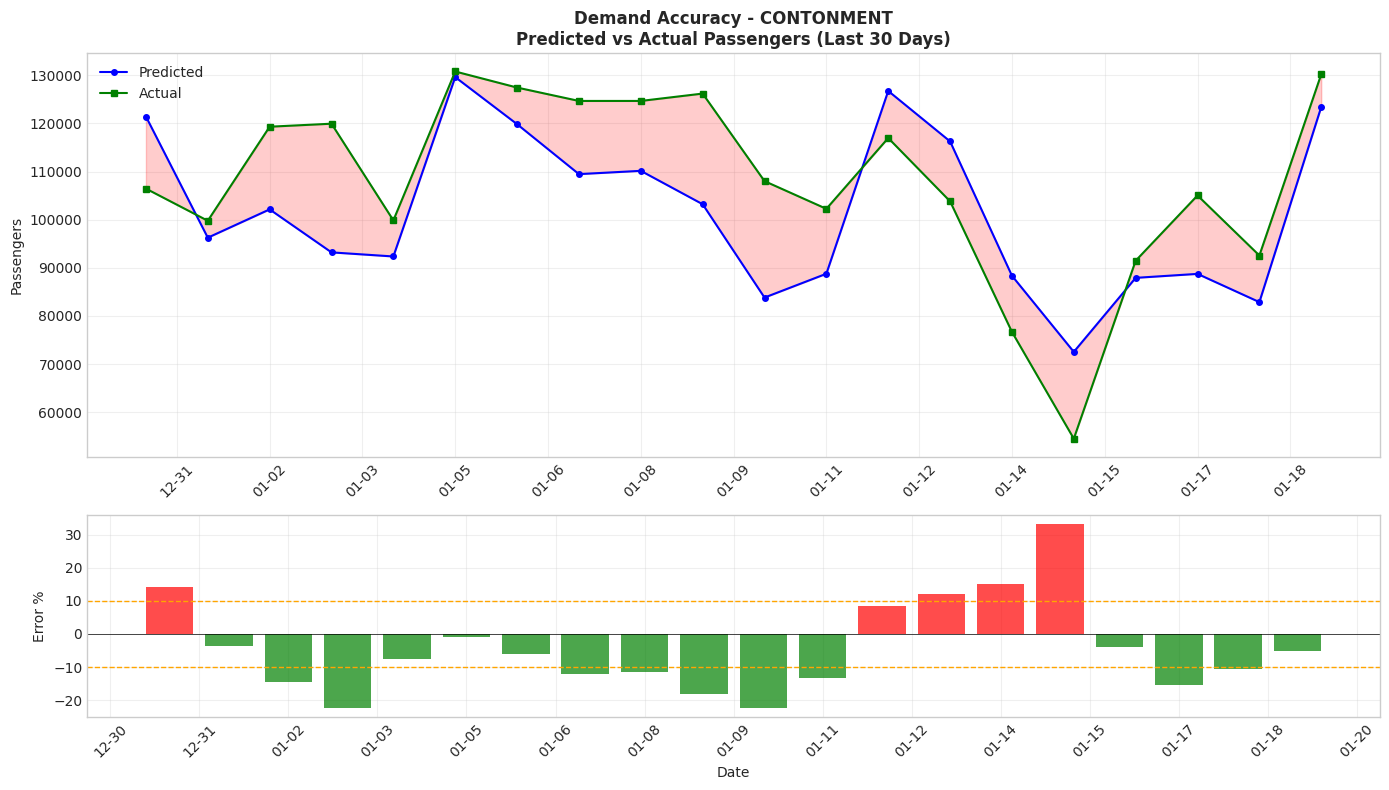


Demand Accuracy Table (Last 30 Days):
      Date Predicted  Actual   Error Error %
2025-12-31   121,422 106,444  14,978   14.1%
2026-01-01    96,260  99,774  -3,514   -3.5%
2026-01-02   102,137 119,302 -17,165  -14.4%
2026-01-03    93,209 119,928 -26,719  -22.3%
2026-01-04    92,359  99,853  -7,494   -7.5%
2026-01-05   129,600 130,767  -1,167   -0.9%
2026-01-06   119,826 127,431  -7,605   -6.0%
2026-01-07   109,456 124,653 -15,197  -12.2%
2026-01-08   110,141 124,652 -14,511  -11.6%
2026-01-09   103,207 126,181 -22,974  -18.2%
2026-01-10    83,826 108,004 -24,178  -22.4%
2026-01-11    88,773 102,252 -13,479  -13.2%
2026-01-12   126,727 116,951   9,776    8.4%
2026-01-13   116,252 103,810  12,442   12.0%
2026-01-14    88,362  76,699  11,663   15.2%
2026-01-15    72,548  54,525  18,023   33.1%
2026-01-16    87,919  91,475  -3,556   -3.9%
2026-01-17    88,743 105,031 -16,288  -15.5%
2026-01-18    82,883  92,560  -9,677  -10.5%
2026-01-19   123,399 130,184  -6,785   -5.2%

---------------

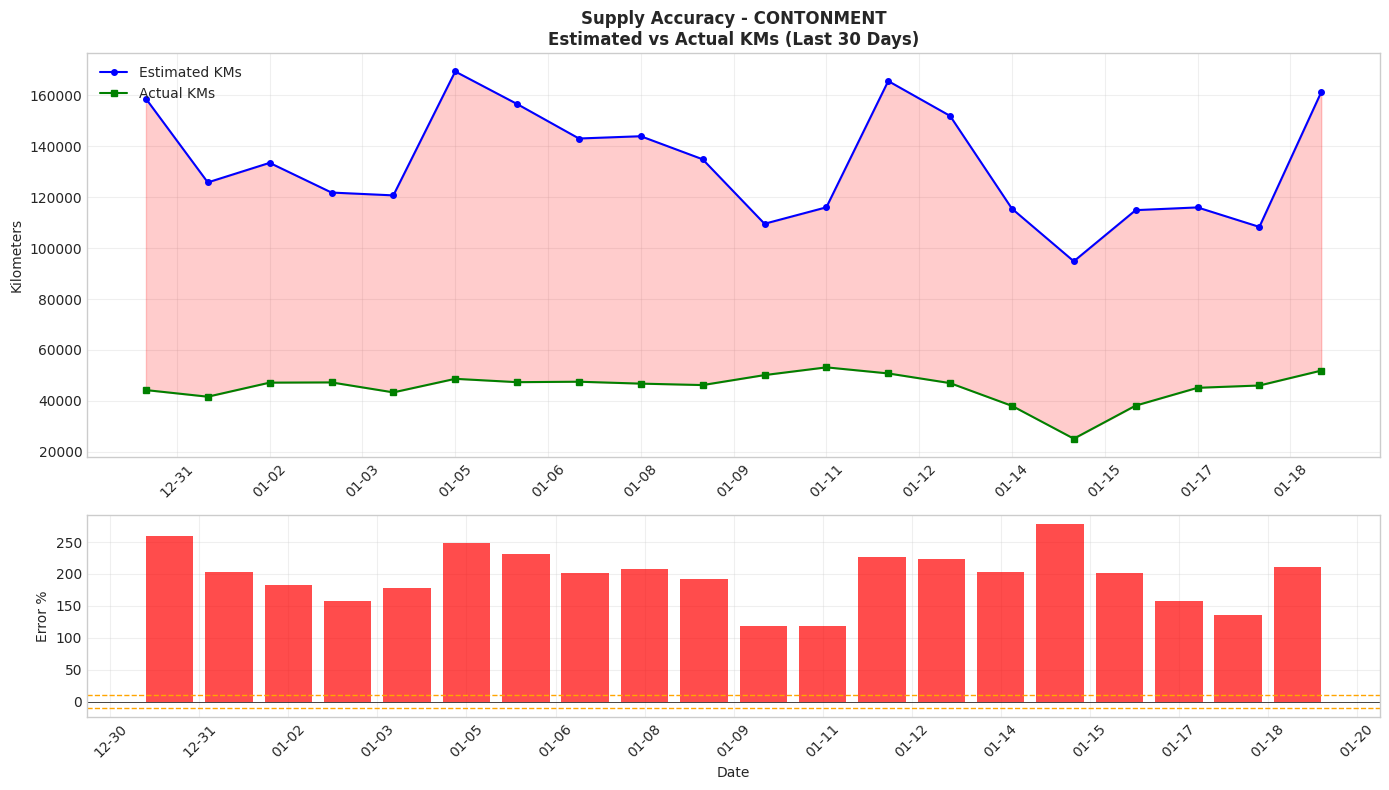


Supply Accuracy Table (Last 30 Days):
      Date Estimated KMs Actual KMs   Error Error %
2025-12-31       158,721     44,224 114,497  258.9%
2026-01-01       125,830     41,621  84,209  202.3%
2026-01-02       133,512     47,149  86,363  183.2%
2026-01-03       121,842     47,235  74,607  157.9%
2026-01-04       120,731     43,317  77,414  178.7%
2026-01-05       169,411     48,647 120,764  248.2%
2026-01-06       156,636     47,332 109,304  230.9%
2026-01-07       143,080     47,508  95,572  201.2%
2026-01-08       143,975     46,759  97,216  207.9%
2026-01-09       134,911     46,191  88,720  192.1%
2026-01-10       109,576     50,113  59,463  118.7%
2026-01-11       116,044     53,154  62,890  118.3%
2026-01-12       165,657     50,763 114,894  226.3%
2026-01-13       151,964     46,960 105,004  223.6%
2026-01-14       115,506     38,025  77,481  203.8%
2026-01-15        94,834     25,122  69,712  277.5%
2026-01-16       114,927     38,118  76,809  201.5%
2026-01-17       116,004 

In [35]:
# =============================================================================
# SHOW DASHBOARD FOR SELECTED DEPOT
# =============================================================================

if SELECTED_DEPOT:
    show_depot_dashboard(
        depot=SELECTED_DEPOT,
        predictions_df=predictions_df,
        schedules=schedules,
        use_plotly=PLOTLY_AVAILABLE  # Set to False to force matplotlib
    )
else:
    print("No depot selected.")

In [36]:
# =============================================================================
# SHOW DASHBOARD FOR ALL DEPOTS
# Uncomment to run for all depots
# =============================================================================

# for depot in DEPOTS:
#     show_depot_dashboard(
#         depot=depot,
#         predictions_df=predictions_df,
#         schedules=schedules,
#         use_plotly=PLOTLY_AVAILABLE
#     )

## 5. Individual Depot Dashboards

Quick access cells for each depot.


################################################################################
#  DEPOT: CONTONMENT
################################################################################

ACCURACY SUMMARY - CONTONMENT

DEMAND ACCURACY (Passenger Predictions):
----------------------------------------
  Records                  : 20
  Mean Error %             : -4.2%
  Mean Abs Error %         : 12.5%
  Median Abs Error %       : 12.1%
  Max Over-estimate        : 33.1%
  Max Under-estimate       : -22.4%
  Within ±10%              : 35.0%
  Within ±20%              : 85.0%

SUPPLY ACCURACY (KM Estimates):
----------------------------------------
  Records                  : 20
  Mean Error %             : 196.7%
  Mean Abs Error %         : 196.7%
  Median Abs Error %       : 201.9%
  Max Over-estimate        : 277.5%
  Max Under-estimate       : 118.3%
  Within ±10%              : 0.0%
  Within ±20%              : 0.0%

---------------------------------------------------------------------

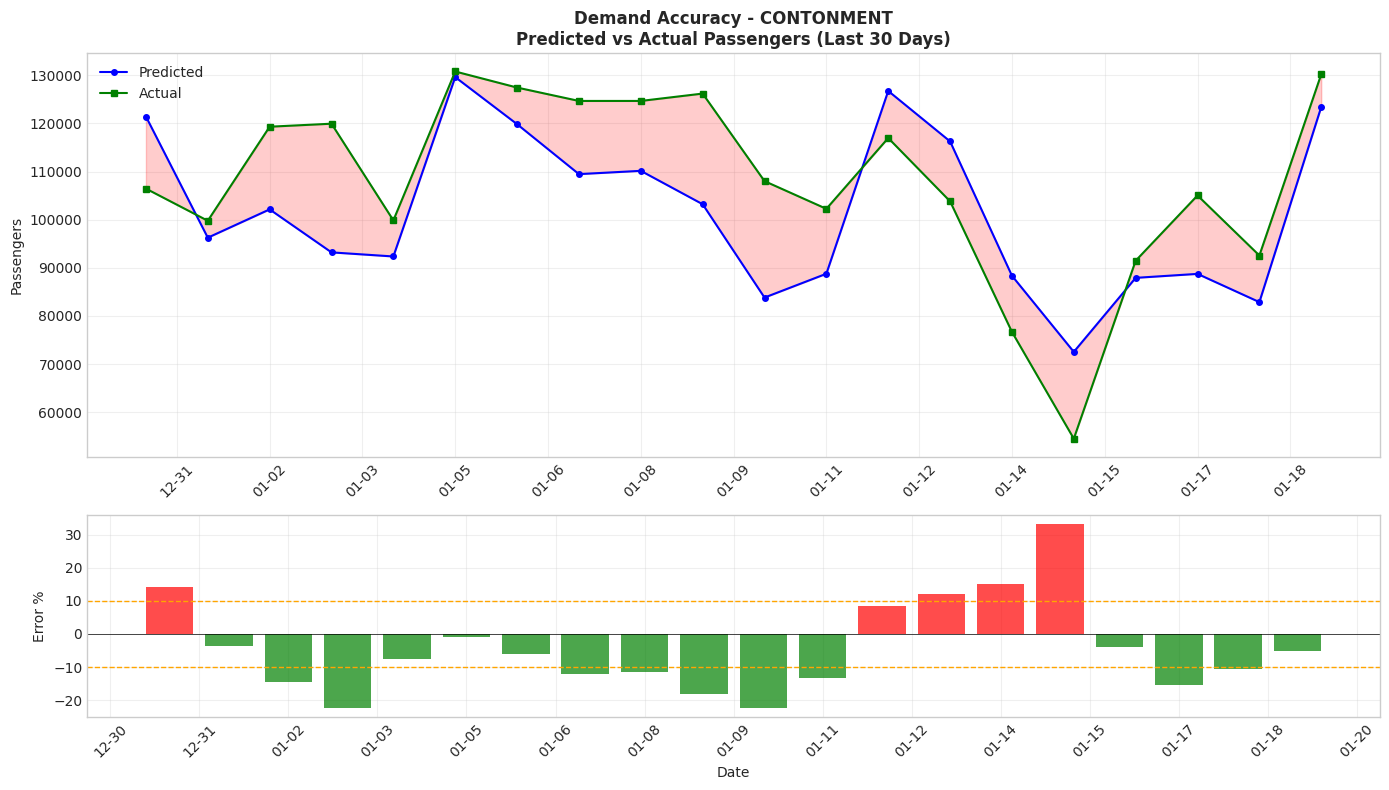


Demand Accuracy Table (Last 30 Days):
      Date Predicted  Actual   Error Error %
2025-12-31   121,422 106,444  14,978   14.1%
2026-01-01    96,260  99,774  -3,514   -3.5%
2026-01-02   102,137 119,302 -17,165  -14.4%
2026-01-03    93,209 119,928 -26,719  -22.3%
2026-01-04    92,359  99,853  -7,494   -7.5%
2026-01-05   129,600 130,767  -1,167   -0.9%
2026-01-06   119,826 127,431  -7,605   -6.0%
2026-01-07   109,456 124,653 -15,197  -12.2%
2026-01-08   110,141 124,652 -14,511  -11.6%
2026-01-09   103,207 126,181 -22,974  -18.2%
2026-01-10    83,826 108,004 -24,178  -22.4%
2026-01-11    88,773 102,252 -13,479  -13.2%
2026-01-12   126,727 116,951   9,776    8.4%
2026-01-13   116,252 103,810  12,442   12.0%
2026-01-14    88,362  76,699  11,663   15.2%
2026-01-15    72,548  54,525  18,023   33.1%
2026-01-16    87,919  91,475  -3,556   -3.9%
2026-01-17    88,743 105,031 -16,288  -15.5%
2026-01-18    82,883  92,560  -9,677  -10.5%
2026-01-19   123,399 130,184  -6,785   -5.2%

---------------

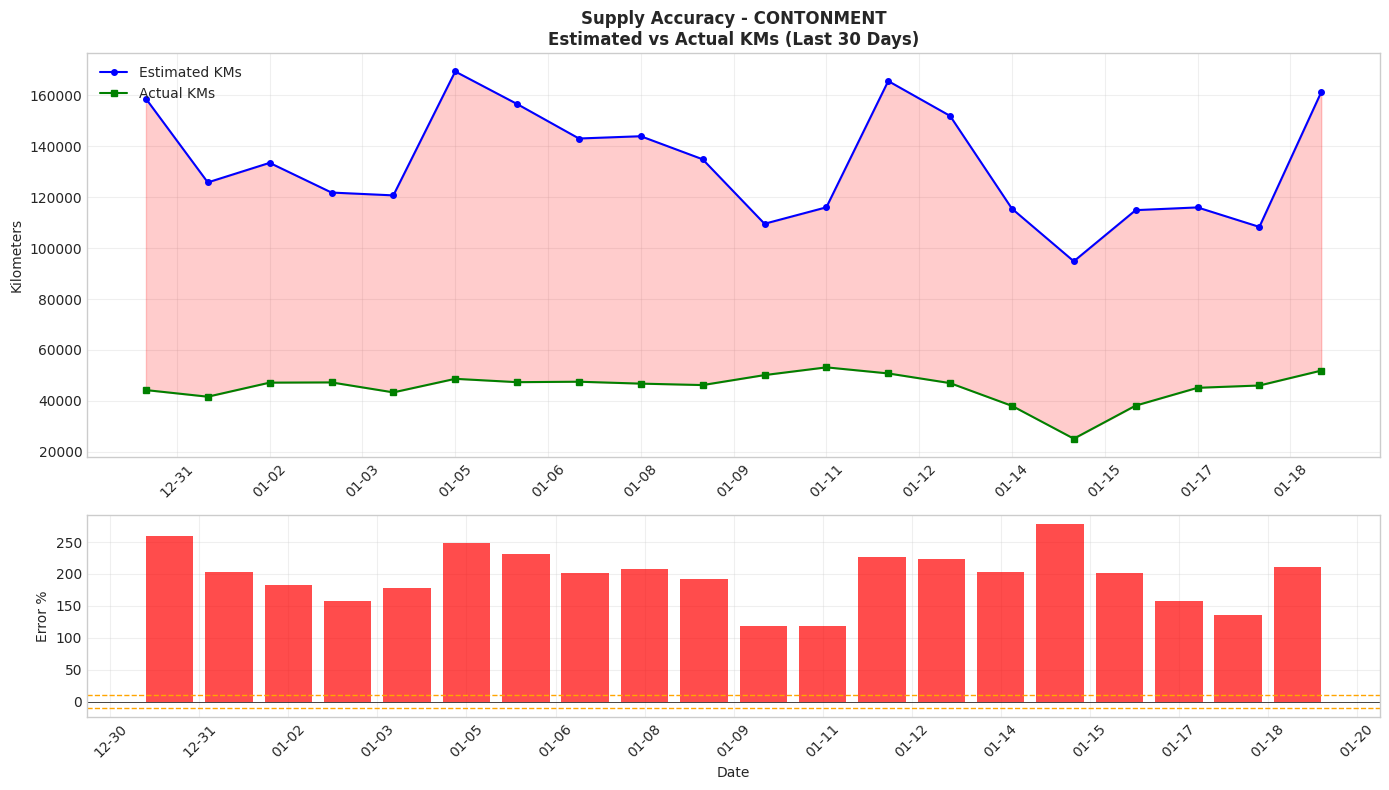


Supply Accuracy Table (Last 30 Days):
      Date Estimated KMs Actual KMs   Error Error %
2025-12-31       158,721     44,224 114,497  258.9%
2026-01-01       125,830     41,621  84,209  202.3%
2026-01-02       133,512     47,149  86,363  183.2%
2026-01-03       121,842     47,235  74,607  157.9%
2026-01-04       120,731     43,317  77,414  178.7%
2026-01-05       169,411     48,647 120,764  248.2%
2026-01-06       156,636     47,332 109,304  230.9%
2026-01-07       143,080     47,508  95,572  201.2%
2026-01-08       143,975     46,759  97,216  207.9%
2026-01-09       134,911     46,191  88,720  192.1%
2026-01-10       109,576     50,113  59,463  118.7%
2026-01-11       116,044     53,154  62,890  118.3%
2026-01-12       165,657     50,763 114,894  226.3%
2026-01-13       151,964     46,960 105,004  223.6%
2026-01-14       115,506     38,025  77,481  203.8%
2026-01-15        94,834     25,122  69,712  277.5%
2026-01-16       114,927     38,118  76,809  201.5%
2026-01-17       116,004 

In [37]:
# =============================================================================
# DEPOT 1: CONTONMENT
# =============================================================================

if "CONTONMENT" in DEPOTS:
    show_depot_dashboard("CONTONMENT", predictions_df, schedules, use_plotly=PLOTLY_AVAILABLE)
else:
    print("CONTONMENT depot not available in data.")


################################################################################
#  DEPOT: KARIMNAGAR-I
################################################################################

ACCURACY SUMMARY - KARIMNAGAR-I

DEMAND ACCURACY (Passenger Predictions):
----------------------------------------
  Records                  : 20
  Mean Error %             : 0.7%
  Mean Abs Error %         : 5.3%
  Median Abs Error %       : 5.1%
  Max Over-estimate        : 14.1%
  Max Under-estimate       : -10.5%
  Within ±10%              : 90.0%
  Within ±20%              : 100.0%

SUPPLY ACCURACY (KM Estimates):
----------------------------------------
  Records                  : 20
  Mean Error %             : 32.2%
  Mean Abs Error %         : 32.5%
  Median Abs Error %       : 33.9%
  Max Over-estimate        : 52.4%
  Max Under-estimate       : -3.1%
  Within ±10%              : 10.0%
  Within ±20%              : 15.0%

----------------------------------------------------------------------

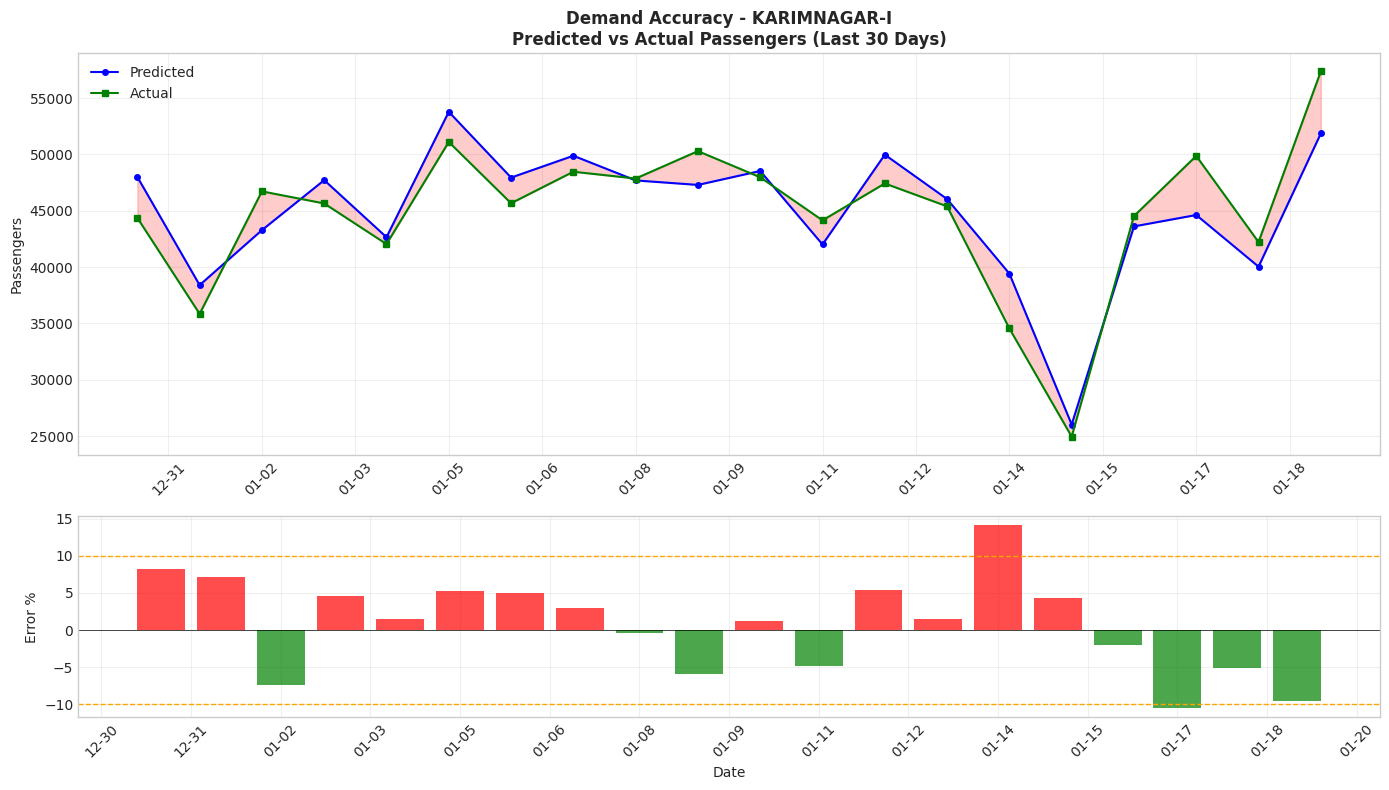


Demand Accuracy Table (Last 30 Days):
      Date Predicted Actual  Error Error %
2025-12-31    48,007 44,374  3,633    8.2%
2026-01-01    38,402 35,846  2,556    7.1%
2026-01-02    43,282 46,725 -3,443   -7.4%
2026-01-03    47,721 45,652  2,069    4.5%
2026-01-04    42,653 42,043    610    1.5%
2026-01-05    53,787 51,110  2,677    5.2%
2026-01-06    47,948 45,669  2,279    5.0%
2026-01-07    49,887 48,468  1,419    2.9%
2026-01-08    47,696 47,864   -168   -0.4%
2026-01-09    47,297 50,298 -3,001   -6.0%
2026-01-10    48,535 47,975    560    1.2%
2026-01-11    42,011 44,151 -2,140   -4.8%
2026-01-12    49,981 47,425  2,556    5.4%
2026-01-13    46,042 45,395    647    1.4%
2026-01-14    39,420 34,551  4,869   14.1%
2026-01-15    26,024 24,950  1,074    4.3%
2026-01-16    43,613 44,532   -919   -2.1%
2026-01-17    44,626 49,870 -5,244  -10.5%
2026-01-18    40,039 42,225 -2,186   -5.2%
2026-01-19    51,864 57,377 -5,513   -9.6%

---------------------------------------------------------

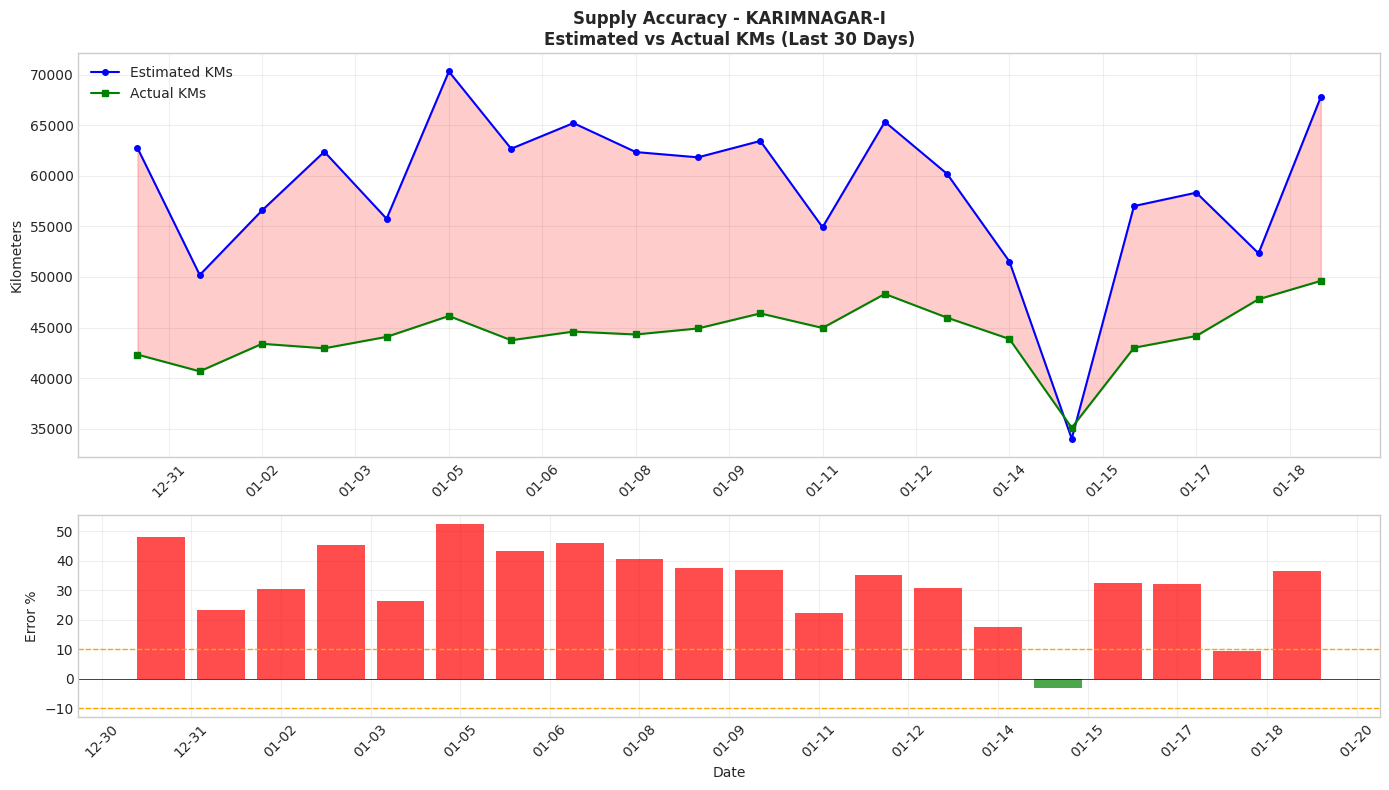


Supply Accuracy Table (Last 30 Days):
      Date Estimated KMs Actual KMs  Error Error %
2025-12-31        62,754     42,329 20,425   48.3%
2026-01-01        50,199     40,676  9,523   23.4%
2026-01-02        56,578     43,397 13,181   30.4%
2026-01-03        62,381     42,951 19,430   45.2%
2026-01-04        55,756     44,081 11,675   26.5%
2026-01-05        70,310     46,144 24,166   52.4%
2026-01-06        62,677     43,749 18,928   43.3%
2026-01-07        65,212     44,603 20,609   46.2%
2026-01-08        62,348     44,317 18,031   40.7%
2026-01-09        61,826     44,914 16,912   37.7%
2026-01-10        63,445     46,401 17,044   36.7%
2026-01-11        54,917     44,962  9,955   22.1%
2026-01-12        65,335     48,325 17,010   35.2%
2026-01-13        60,186     45,977 14,209   30.9%
2026-01-14        51,529     43,873  7,656   17.5%
2026-01-15        34,018     35,103 -1,085   -3.1%
2026-01-16        57,010     43,004 14,006   32.6%
2026-01-17        58,334     44,170 14,164 

In [38]:
# =============================================================================
# DEPOT 2: KARIMNAGAR-I
# =============================================================================

if "KARIMNAGAR-I" in DEPOTS:
    show_depot_dashboard("KARIMNAGAR-I", predictions_df, schedules, use_plotly=PLOTLY_AVAILABLE)
else:
    print("KARIMNAGAR-I depot not available in data.")


################################################################################
#  DEPOT: NIZAMABAD-I
################################################################################

ACCURACY SUMMARY - NIZAMABAD-I

DEMAND ACCURACY (Passenger Predictions):
----------------------------------------
  Records                  : 20
  Mean Error %             : 2.7%
  Mean Abs Error %         : 7.7%
  Median Abs Error %       : 5.5%
  Max Over-estimate        : 29.9%
  Max Under-estimate       : -12.1%
  Within ±10%              : 60.0%
  Within ±20%              : 90.0%

SUPPLY ACCURACY (KM Estimates):
----------------------------------------
  Records                  : 20
  Mean Error %             : 13.4%
  Mean Abs Error %         : 14.3%
  Median Abs Error %       : 13.0%
  Max Over-estimate        : 26.5%
  Max Under-estimate       : -5.7%
  Within ±10%              : 35.0%
  Within ±20%              : 75.0%

----------------------------------------------------------------------
DE

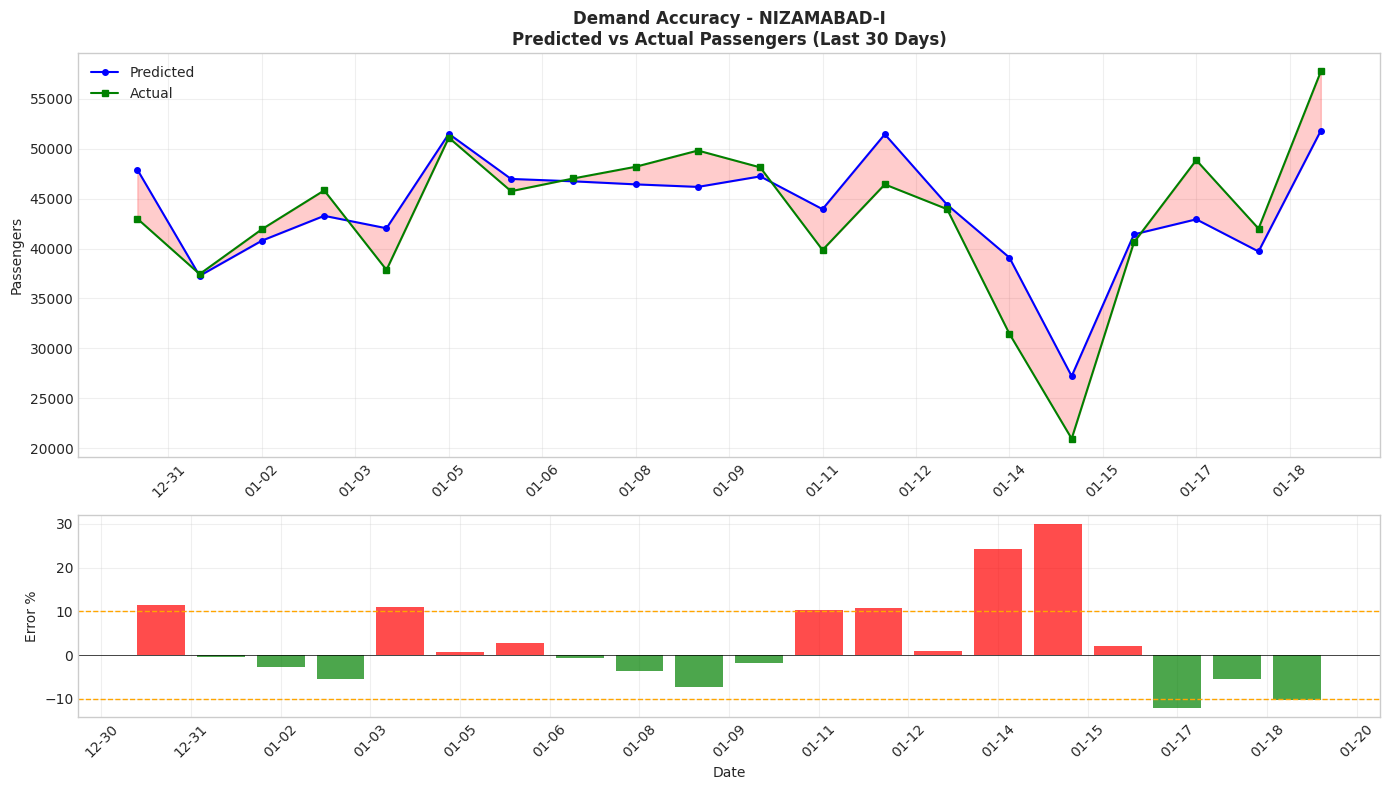


Demand Accuracy Table (Last 30 Days):
      Date Predicted Actual  Error Error %
2025-12-31    47,904 42,986  4,918   11.4%
2026-01-01    37,264 37,438   -174   -0.5%
2026-01-02    40,788 41,931 -1,144   -2.7%
2026-01-03    43,274 45,819 -2,545   -5.6%
2026-01-04    42,029 37,854  4,175   11.0%
2026-01-05    51,485 51,098    387    0.8%
2026-01-06    46,968 45,741  1,227    2.7%
2026-01-07    46,729 47,018   -289   -0.6%
2026-01-08    46,425 48,188 -1,763   -3.7%
2026-01-09    46,171 49,813 -3,642   -7.3%
2026-01-10    47,224 48,125   -901   -1.9%
2026-01-11    43,939 39,850  4,089   10.3%
2026-01-12    51,444 46,420  5,024   10.8%
2026-01-13    44,384 43,943    441    1.0%
2026-01-14    39,093 31,467  7,626   24.2%
2026-01-15    27,215 20,952  6,263   29.9%
2026-01-16    41,418 40,619    799    2.0%
2026-01-17    42,924 48,853 -5,929  -12.1%
2026-01-18    39,702 41,993 -2,291   -5.5%
2026-01-19    51,804 57,730 -5,926  -10.3%

---------------------------------------------------------

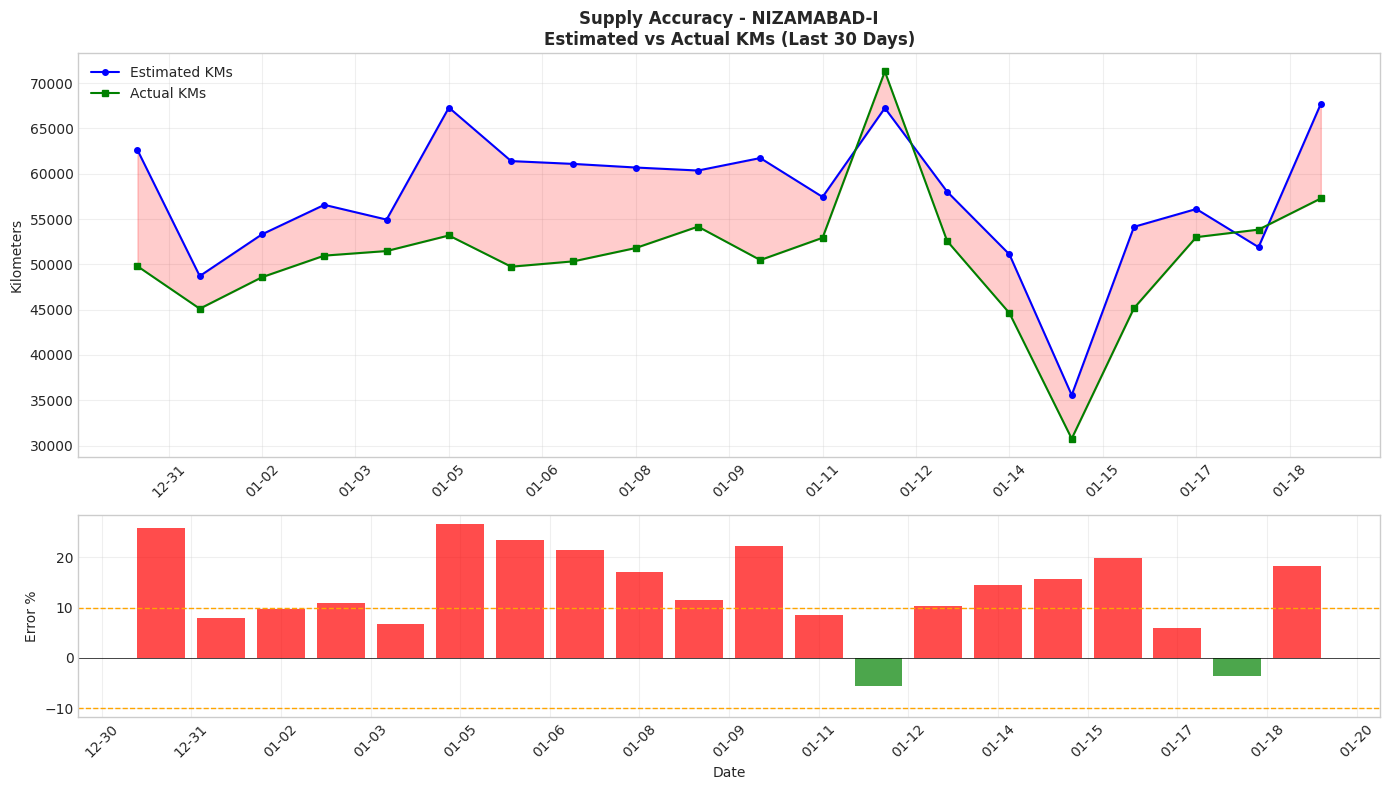


Supply Accuracy Table (Last 30 Days):
      Date Estimated KMs Actual KMs  Error Error %
2025-12-31        62,620     49,795 12,825   25.8%
2026-01-01        48,711     45,107  3,604    8.0%
2026-01-02        53,317     48,585  4,732    9.7%
2026-01-03        56,567     50,965  5,602   11.0%
2026-01-04        54,940     51,469  3,471    6.7%
2026-01-05        67,300     53,187 14,113   26.5%
2026-01-06        61,396     49,743 11,653   23.4%
2026-01-07        61,083     50,333 10,750   21.4%
2026-01-08        60,686     51,804  8,882   17.1%
2026-01-09        60,354     54,164  6,190   11.4%
2026-01-10        61,731     50,475 11,256   22.3%
2026-01-11        57,437     52,933  4,504    8.5%
2026-01-12        67,247     71,282 -4,035   -5.7%
2026-01-13        58,019     52,575  5,444   10.4%
2026-01-14        51,102     44,622  6,480   14.5%
2026-01-15        35,575     30,764  4,811   15.6%
2026-01-16        54,141     45,168  8,973   19.9%
2026-01-17        56,110     53,004  3,106 

In [39]:
# =============================================================================
# DEPOT 3: NIZAMABAD-I
# =============================================================================

if "NIZAMABAD-I" in DEPOTS:
    show_depot_dashboard("NIZAMABAD-I", predictions_df, schedules, use_plotly=PLOTLY_AVAILABLE)
else:
    print("NIZAMABAD-I depot not available in data.")


################################################################################
#  DEPOT: WARANGAL-I
################################################################################

ACCURACY SUMMARY - WARANGAL-I

DEMAND ACCURACY (Passenger Predictions):
----------------------------------------
  Records                  : 20
  Mean Error %             : -0.6%
  Mean Abs Error %         : 6.6%
  Median Abs Error %       : 6.0%
  Max Over-estimate        : 13.2%
  Max Under-estimate       : -17.6%
  Within ±10%              : 75.0%
  Within ±20%              : 100.0%

SUPPLY ACCURACY (KM Estimates):
----------------------------------------
  Records                  : 20
  Mean Error %             : -19.8%
  Mean Abs Error %         : 19.8%
  Median Abs Error %       : 18.0%
  Max Over-estimate        : -7.5%
  Max Under-estimate       : -47.4%
  Within ±10%              : 10.0%
  Within ±20%              : 60.0%

----------------------------------------------------------------------


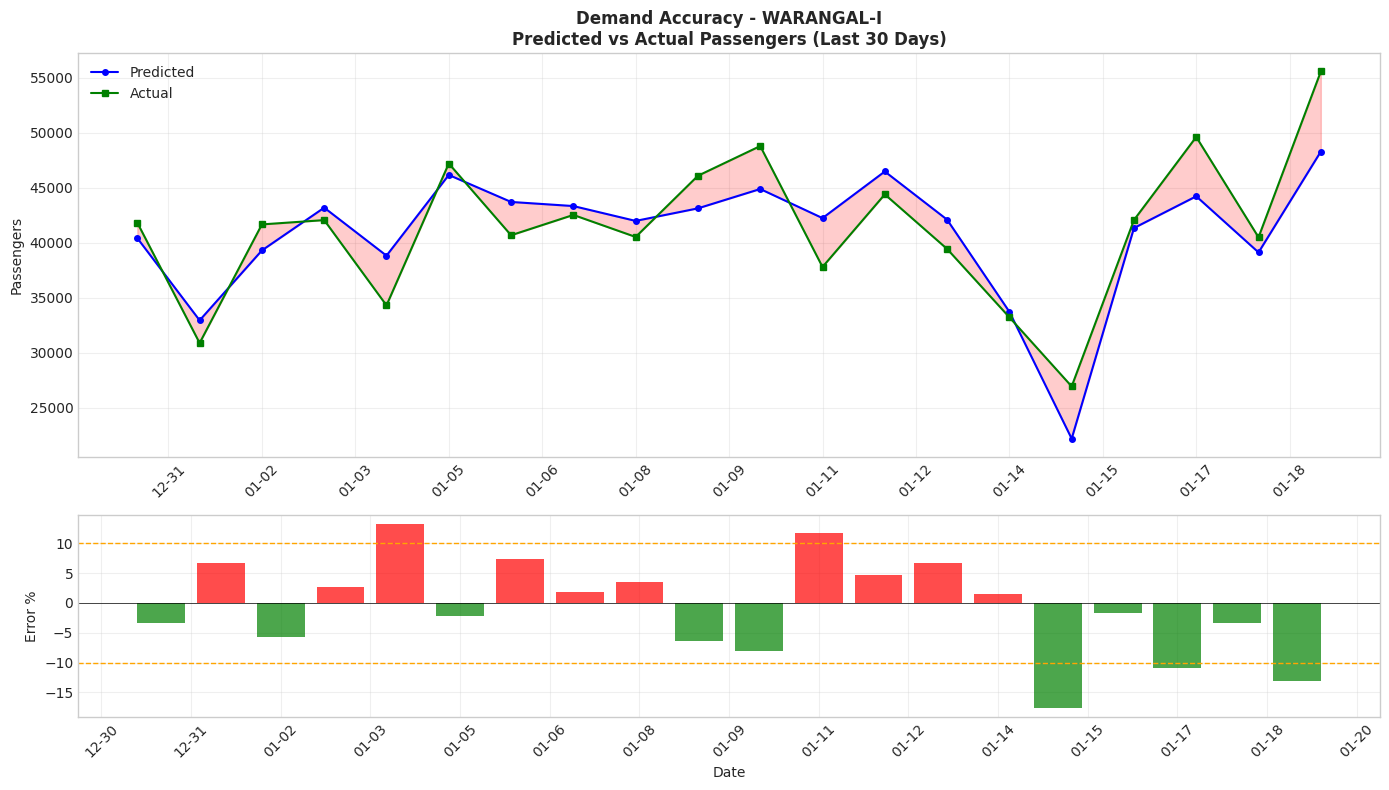


Demand Accuracy Table (Last 30 Days):
      Date Predicted Actual  Error Error %
2025-12-31    40,434 41,839 -1,405   -3.4%
2026-01-01    32,965 30,902  2,063    6.7%
2026-01-02    39,322 41,686 -2,364   -5.7%
2026-01-03    43,208 42,077  1,131    2.7%
2026-01-04    38,844 34,323  4,521   13.2%
2026-01-05    46,182 47,222 -1,040   -2.2%
2026-01-06    43,728 40,699  3,029    7.4%
2026-01-07    43,354 42,547    807    1.9%
2026-01-08    42,003 40,544  1,459    3.6%
2026-01-09    43,146 46,109 -2,963   -6.4%
2026-01-10    44,904 48,809 -3,905   -8.0%
2026-01-11    42,259 37,819  4,440   11.7%
2026-01-12    46,496 44,416  2,080    4.7%
2026-01-13    42,119 39,457  2,662    6.7%
2026-01-14    33,746 33,245    501    1.5%
2026-01-15    22,208 26,960 -4,752  -17.6%
2026-01-16    41,358 42,086   -728   -1.7%
2026-01-17    44,242 49,637 -5,395  -10.9%
2026-01-18    39,140 40,515 -1,375   -3.4%
2026-01-19    48,308 55,586 -7,278  -13.1%

---------------------------------------------------------

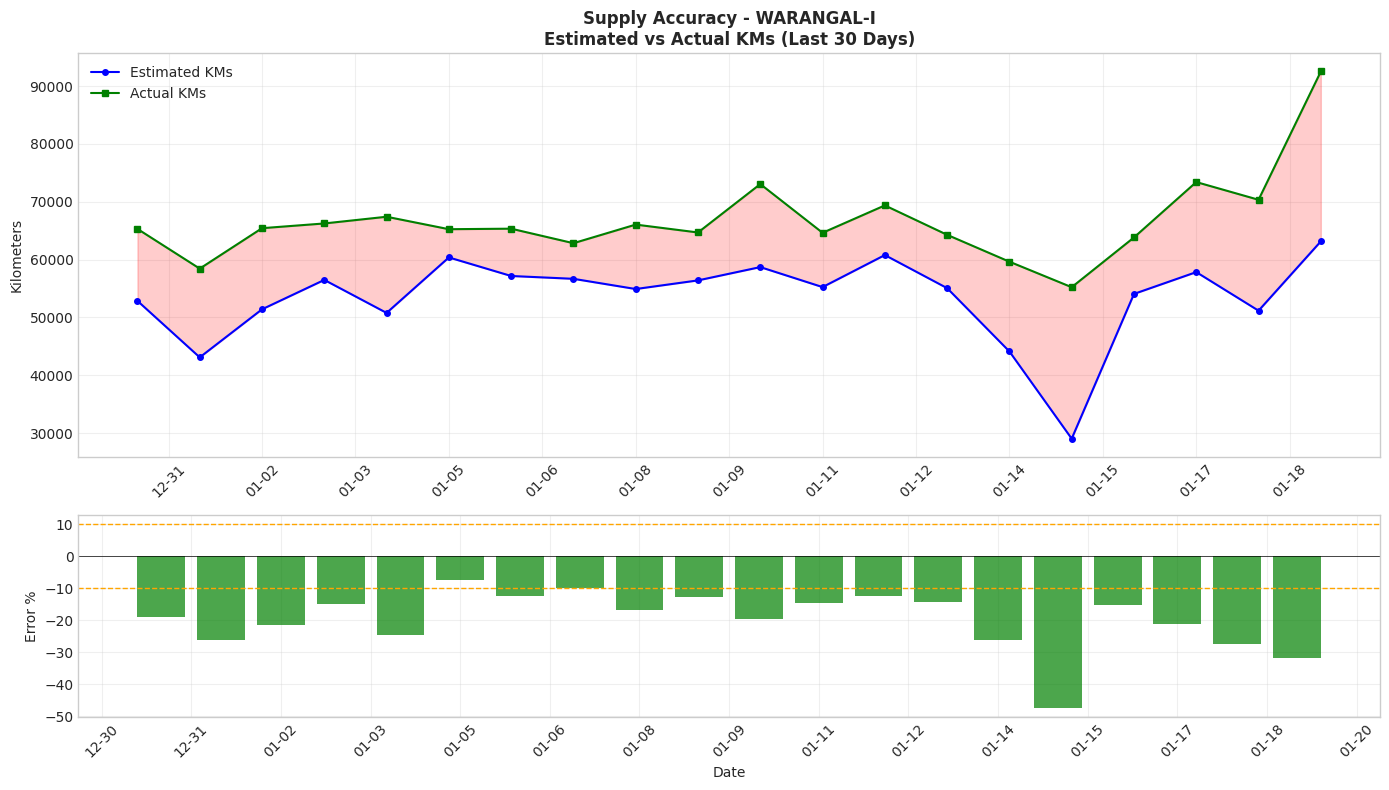


Supply Accuracy Table (Last 30 Days):
      Date Estimated KMs Actual KMs   Error Error %
2025-12-31        52,855     65,300 -12,445  -19.1%
2026-01-01        43,092     58,434 -15,342  -26.3%
2026-01-02        51,402     65,426 -14,024  -21.4%
2026-01-03        56,482     66,244  -9,762  -14.7%
2026-01-04        50,777     67,404 -16,627  -24.7%
2026-01-05        60,368     65,250  -4,882   -7.5%
2026-01-06        57,161     65,340  -8,179  -12.5%
2026-01-07        56,672     62,830  -6,158   -9.8%
2026-01-08        54,906     66,048 -11,142  -16.9%
2026-01-09        56,400     64,684  -8,284  -12.8%
2026-01-10        58,698     73,054 -14,356  -19.7%
2026-01-11        55,241     64,630  -9,389  -14.5%
2026-01-12        60,780     69,365  -8,585  -12.4%
2026-01-13        55,058     64,278  -9,220  -14.3%
2026-01-14        44,112     59,632 -15,520  -26.0%
2026-01-15        29,031     55,222 -26,191  -47.4%
2026-01-16        54,062     63,826  -9,764  -15.3%
2026-01-17        57,832 

In [40]:
# =============================================================================
# DEPOT 4: WARANGAL-I
# =============================================================================

if "WARANGAL-I" in DEPOTS:
    show_depot_dashboard("WARANGAL-I", predictions_df, schedules, use_plotly=PLOTLY_AVAILABLE)
else:
    print("WARANGAL-I depot not available in data.")

## 6. Export Dashboard Data

In [41]:
# =============================================================================
# EXPORT DASHBOARD DATA TO EXCEL
# =============================================================================

def export_dashboard_to_excel(predictions_df: pd.DataFrame, schedules: dict, output_path: Path):
    """
    Export all dashboard data to a single Excel file with multiple sheets.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
        # Summary sheet
        if len(predictions_df) > 0:
            summary_rows = []
            for depot in DEPOTS:
                demand_df = get_demand_accuracy_data(predictions_df, depot)
                supply_df = get_supply_accuracy_data(predictions_df, depot)
                
                row = {
                    "Depot": depot,
                    "Demand_Records": len(demand_df),
                    "Demand_MAPE": demand_df['Error %'].abs().mean() if len(demand_df) > 0 else None,
                    "Supply_Records": len(supply_df),
                    "Supply_MAPE": supply_df['Error %'].abs().mean() if len(supply_df) > 0 else None,
                }
                summary_rows.append(row)
            
            pd.DataFrame(summary_rows).to_excel(writer, sheet_name="Summary", index=False)
        
        # Per-depot sheets
        for depot in DEPOTS:
            # Demand accuracy
            demand_df = get_demand_accuracy_data(predictions_df, depot)
            if len(demand_df) > 0:
                sheet_name = f"{depot[:20]}_Demand"
                demand_df.to_excel(writer, sheet_name=sheet_name, index=False)
            
            # Supply accuracy
            supply_df = get_supply_accuracy_data(predictions_df, depot)
            if len(supply_df) > 0:
                sheet_name = f"{depot[:20]}_Supply"
                supply_df.to_excel(writer, sheet_name=sheet_name, index=False)
            
            # Schedule
            if depot in schedules:
                sheet_name = f"{depot[:20]}_Schedule"
                schedules[depot].to_excel(writer, sheet_name=sheet_name, index=False)
    
    print(f"Dashboard exported to: {output_path}")


# Export to Excel
export_path = OUTPUT_DIR / "dashboard" / f"ops_dashboard_{datetime.now().strftime('%Y%m%d')}.xlsx"
# Uncomment to export:
# export_dashboard_to_excel(predictions_df, schedules, export_path)

## 7. Summary

This dashboard provides:

### For Each Depot

1. **Demand Accuracy (Last 30 Days)**
   - Table: Date, Predicted, Actual, Error, Error %
   - Graph: Predicted vs Actual passengers with error bars
   - Metrics: MAPE, within ±10%, within ±20%

2. **Supply Accuracy (Last 30 Days)**
   - Table: Date, Estimated KMs, Actual KMs, Error, Error %
   - Graph: Estimated vs Actual KMs with error bars
   - Metrics: MAPE, within ±10%, within ±20%

3. **Daily Schedule**
   - Full schedule table from latest schedule file
   - Summary metrics (total trips, buses, KMs)

### Data Sources

| Data | Source |
|------|--------|
| Predictions & Actuals | `output/predictions/daily_predictions.parquet` |
| Schedules | `output/dynamic_schedule/[date]/schedule_[depot]_[date].xlsx` |

### Usage

1. Run cells 1-4 to load data
2. View overall summary in Section 4
3. Select a depot and run the dashboard cell
4. Or use Section 5 for quick access to individual depots
5. Export to Excel using Section 6